# Angle Map Fitting

Load the three angle maps collected in Lab 9 and fit them into a common world frame using interactive sliders. Each map is a ToF scan taken while the robot spins in place at a marked location.

AngleMap1 is fixed as the reference frame. AngleMap2 and AngleMap3 are placed relative to it with adjustable pose `(x, y, phi)`. AngleMap3 sits spatially between 1 and 2.

## Transformation

Every ToF sample is stored as `(theta, d)` where `theta` is the robot's yaw during the reading and `d` is the measured distance. In 2D homogeneous form, a reading is converted to the world frame by

```
p_world = T_world_robot(x, y, phi) * T_robot_sensor(theta) * [d, 0, 1]^T
```

where

```
T_world_robot(x, y, phi) = | cos(phi)  -sin(phi)  x |
                          | sin(phi)   cos(phi)  y |
                          |    0          0      1 |

T_robot_sensor(theta)   = | cos(theta) -sin(theta) 0 |
                          | sin(theta)  cos(theta) 0 |
                          |    0           0       1 |
```

The product of the two rotations is equivalent to rotating by `phi + theta`, which is why the sliders only need `(x, y, phi)` for each scan.

In [5]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ipywidgets import FloatSlider, VBox, HBox, Label, Button, Output

IMAGE_DIR = Path('../images')
MAP_FILES = ['AngleMap1.csv', 'AngleMap2.csv', 'AngleMap3.csv']

def load_map(path):
    df = pd.read_csv(path)
    theta = np.deg2rad(df['1'].to_numpy())
    d = df['2'].to_numpy() / 1000.0  # mm -> m
    return theta, d

maps = [load_map(IMAGE_DIR / f) for f in MAP_FILES]
for name, (theta, d) in zip(MAP_FILES, maps):
    print(f'{name}: {len(theta)} points, d in [{d.min():.2f}, {d.max():.2f}] m')


AngleMap1.csv: 64 points, d in [0.43, 1.96] m
AngleMap2.csv: 64 points, d in [0.55, 1.75] m
AngleMap3.csv: 64 points, d in [0.27, 1.47] m


In [6]:
def transform_scan(theta, d, x, y, phi):
    """Apply T_world_robot(x, y, phi) * T_robot_sensor(theta) to each (d, 0) reading."""
    angle = theta + phi
    xs = x + d * np.cos(angle)
    ys = y + d * np.sin(angle)
    return xs, ys

# Pose for each scan. AngleMap1 is the reference at the origin.
INIT = {
    1: dict(x=0.00, y=0.00, phi=np.deg2rad(0.0)),
    2: dict(x=0.45, y=1.75, phi=np.deg2rad(9.0)),
    3: dict(x=0.70, y=0.70, phi=np.deg2rad(-5.0)),
}
COLORS = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:green'}


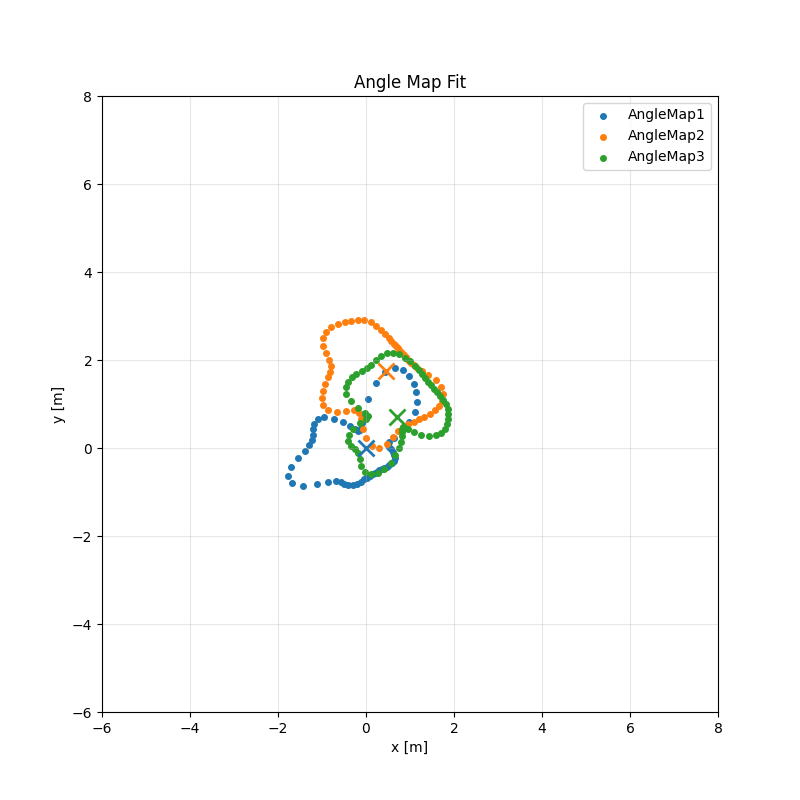

In [7]:
plt.close('all')
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Angle Map Fit')
ax.grid(True, alpha=0.3)

scatters = {}
origins = {}
for i, (theta, d) in enumerate(maps, start=1):
    p = INIT[i]
    xs, ys = transform_scan(theta, d, **p)
    scatters[i] = ax.scatter(xs, ys, s=16, color=COLORS[i], label=f'AngleMap{i}')
    origins[i] = ax.plot([p['x']], [p['y']], marker='x', color=COLORS[i], markersize=12, mew=2)[0]

ax.legend(loc='upper right')
ax.set_xlim(-6, 8)
ax.set_ylim(-6, 8)

def make_sliders(i):
    p = INIT[i]
    sx = FloatSlider(value=p['x'], min=-6, max=8, step=0.05, description=f'x{i}')
    sy = FloatSlider(value=p['y'], min=-6, max=8, step=0.05, description=f'y{i}')
    sphi = FloatSlider(value=np.rad2deg(p['phi']), min=-180, max=180, step=1.0, description=f'phi{i}')
    return sx, sy, sphi

controls = {i: make_sliders(i) for i in (1, 2, 3)}

def redraw(_=None):
    for i, (theta, d) in enumerate(maps, start=1):
        sx, sy, sphi = controls[i]
        xs, ys = transform_scan(theta, d, sx.value, sy.value, np.deg2rad(sphi.value))
        scatters[i].set_offsets(np.column_stack([xs, ys]))
        origins[i].set_data([sx.value], [sy.value])
    fig.canvas.draw_idle()

for trio in controls.values():
    for s in trio:
        s.observe(redraw, names='value')

ui = VBox([
    Label('AngleMap1 (reference):'), HBox(list(controls[1])),
    Label('AngleMap2:'),             HBox(list(controls[2])),
    Label('AngleMap3 (between 1 and 2):'), HBox(list(controls[3])),
])
ui


## Export the current pose

Run the cell below after fitting the maps to print the pose of each scan and a merged `(x, y)` array you can reuse for the line-based map step.

In [8]:
merged = []
for i, (theta, d) in enumerate(maps, start=1):
    sx, sy, sphi = controls[i]
    phi = np.deg2rad(sphi.value)
    xs, ys = transform_scan(theta, d, sx.value, sy.value, phi)
    merged.append(np.column_stack([xs, ys]))
    print(f'AngleMap{i}: x={sx.value:+.3f}  y={sy.value:+.3f}  phi={sphi.value:+.2f} deg')

merged = np.vstack(merged)
print(f'merged shape: {merged.shape}')


AngleMap1: x=+0.000  y=+0.000  phi=+0.00 deg
AngleMap2: x=+0.450  y=+1.750  phi=+9.00 deg
AngleMap3: x=+0.700  y=+0.700  phi=-5.00 deg
merged shape: (192, 2)
